## k-means Clustering


In [2]:
import mglearn
import numpy as np
import scipy as sp
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.decomposition import NMF, PCA

# import jupyterthemes as jt
# from jupyterthemes.stylefx import set_nb_theme

# set_nb_theme('monokai')

In [48]:
from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1
    
x_people = people.data[mask]
y_people = people.target[mask]

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

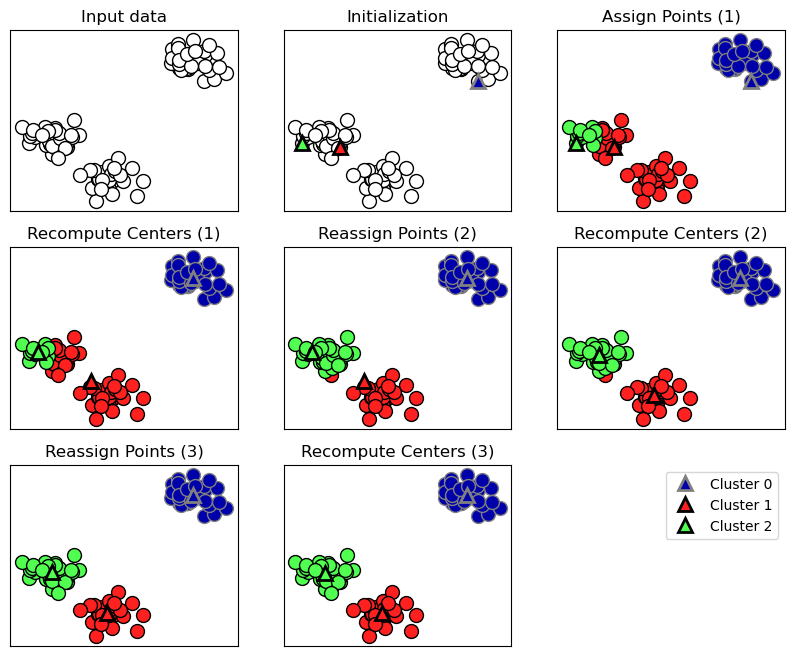

In [6]:
mglearn.plots.plot_kmeans_algorithm()

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# generate synthetic two-dimensional data
x, y = make_blobs(random_state=1)

# build the clustered model
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3)

In [24]:
print('Cluster memberships:\n{}'.format(kmeans.labels_))

Cluster memberships:
[1 0 0 0 2 2 2 0 1 1 0 0 2 1 2 2 2 1 0 0 2 0 2 1 0 2 2 1 1 2 1 1 2 1 0 2 0
 0 0 2 2 0 1 0 0 2 1 1 1 1 0 2 2 2 1 2 0 0 1 1 0 2 2 0 0 2 1 2 1 0 0 0 2 1
 1 0 2 2 1 0 1 0 0 2 1 1 1 1 0 1 2 1 1 0 0 2 2 1 2 1]


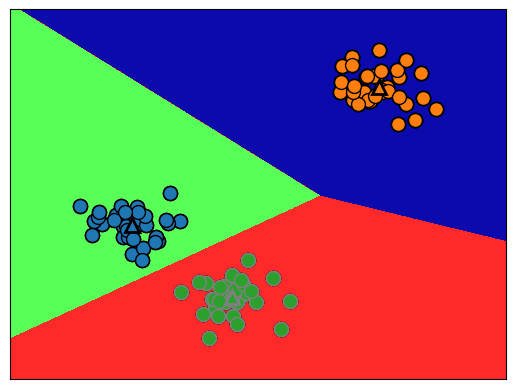

In [29]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

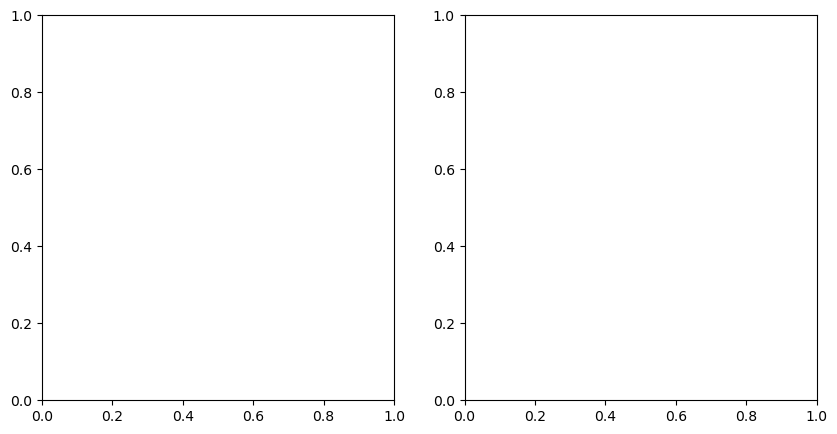

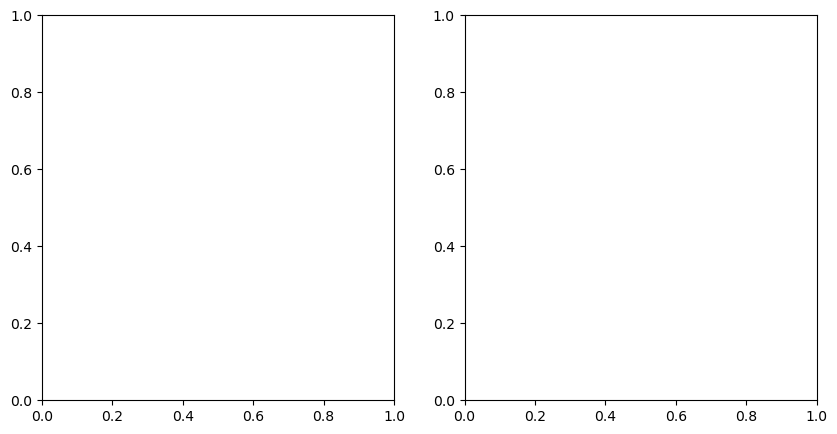

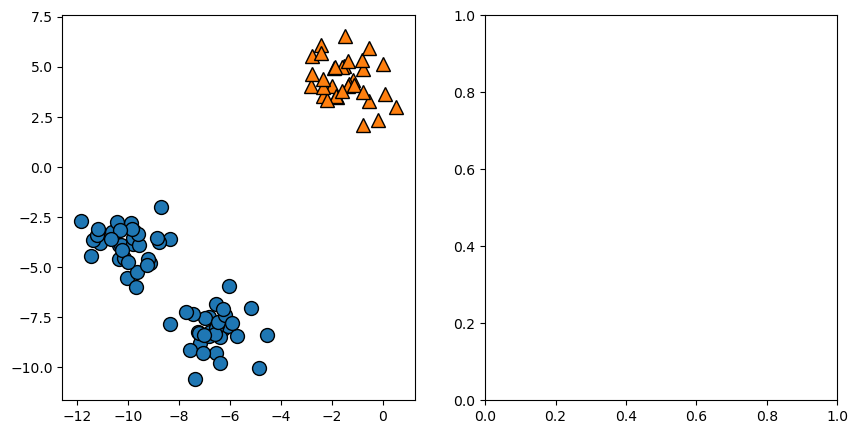

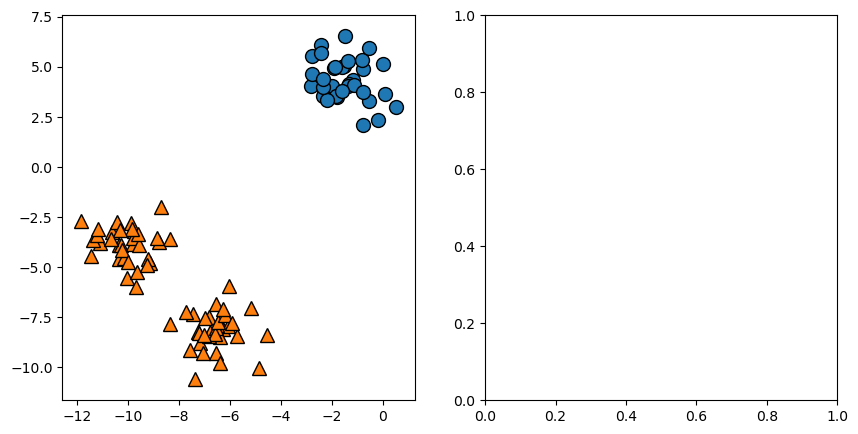

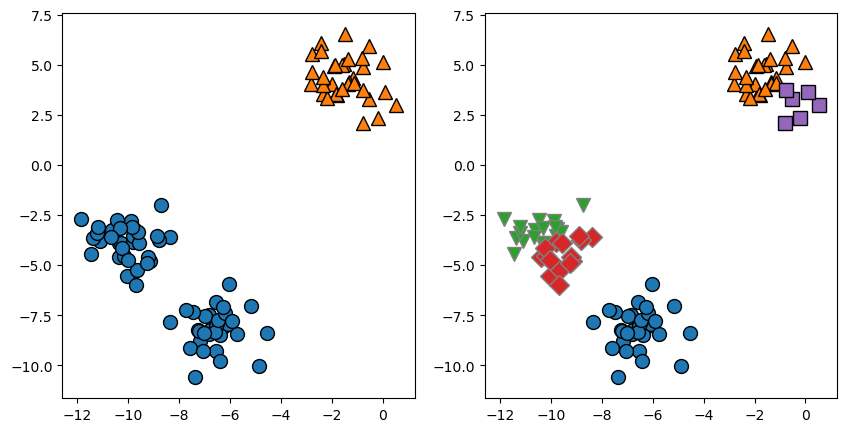

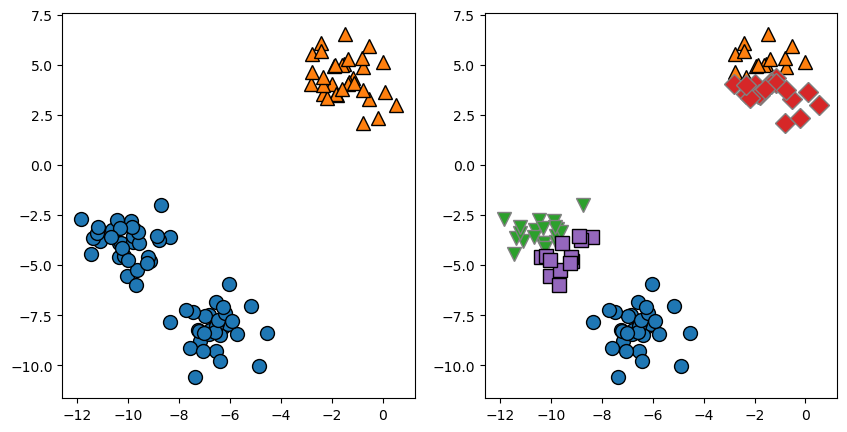

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# using two cluster centers:
kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
assignments = kmeans.labels_

mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[0])

# using five cluster centers:
kmeans = KMeans(n_clusters=5)
kmeans.fit(x)
assignments = kmeans.labels_

mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[1])
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


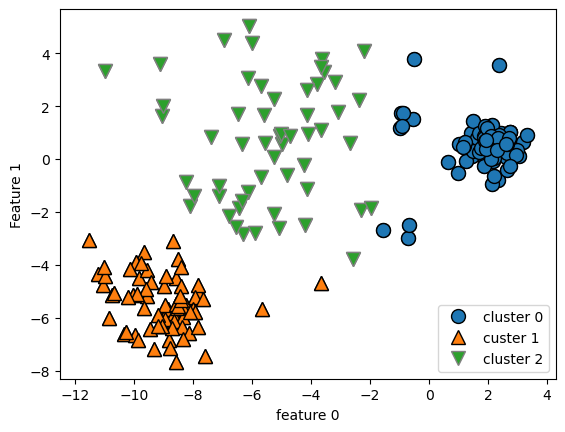

In [37]:
x_varied, y_varied = make_blobs(n_samples=200,
                               cluster_std=[1.0, 2.5, 0.5],
                               random_state=170)
y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(x_varied)

mglearn.discrete_scatter(x_varied[:, 0], x_varied[:, 1], y_pred)
plt.legend(['cluster 0', 'custer 1', 'cluster 2'], loc='best')
plt.xlabel('feature 0')
plt.ylabel('Feature 1')
plt.show()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Text(0, 0.5, 'Feature 1')

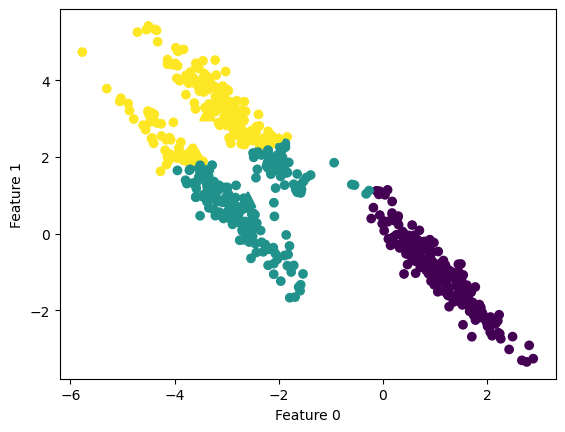

In [41]:
# generate some random cluster data
x, y = make_blobs(random_state=170, n_samples=600)
rng = np.random.RandomState(74)

# transform the data to be stretched
transformation = rng.normal(size=(2, 2))
x = np.dot(x, transformation)

# cluster the data into three clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
y_pred = kmeans.predict(x)

# plot the cluster assignments and cluster centers
plt.scatter(x[:, 0], x[:, 1], c=y_pred)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker='^', c=[0, 1, 2], s=100, linewidth=2)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

In [8]:
# generate synthetic two_moons data (with less noise this time)
from sklearn.datasets import make_moons
x, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# cluster the data into two clusters
kmeans = KMeans(n_clusters=2)
kmeans.fit(x) 
y_pred = kmeans.predict(x)

# plot the cluster assignments and cluster centers
plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker='^', s=100, linewidth=2)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

## Vector quantization, or seeing k-means as decomposition

In [74]:
image_shape = people.images[0].shape
x_train, x_test, y_train, y_test = train_test_split(
    x_people, y_people, stratify=y_people, random_state=0)
nmf = NMF(n_components=100, random_state=0)
nmf.fit(x_train)
pca = PCA(n_components=100, random_state=0)
pca.fit(x_train)
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(x_train)

x_reconstructed_pca = pca.inverse_transform(pca.transform(x_test))
x_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(x_test)]
x_reconstructed_nmf = np.dot(nmf.transform(x_test), nmf.components_)

fig, axes = plt.subplots(3, 5, figsize=(8, 8),
                        subplot_kw={'xticks': (), 'yticks': ()})
fig.suptitle('Extracted components')
for ax, comp_kmeans, comp_pca, comp_nmf in zip(
        axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[2].imshow(comp_kmeans.reshape(image_shape), cmap='Greys_r')
    ax[1].imshow(comp_pca.reshape(image_shape), cmap='Greys_r')
    ax[0].imshow(comp_nmf.reshape(image_shape), cmap='Greys_r')

axes[2, 0].set_ylabel('kmeans')
axes[1, 0].set_ylabel('pca')
axes[0, 0].set_ylabel('nmf')

# fig, axes = plt.subplots(4, 5, subplot_kw={'xticks': (), 'yticks': ()},
#                         figsize=(8, 8))
# fig.suptitle('Reconstruction')
# for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(
#         axes.T, x_test, x_reconstructed_kmeans, x_reconstructed_pca,
#         x_reconstructed_nmf):
    
#     ax[0].imshow(orig.reshape(image_shape))
#     ax[1].imshow(rec_kmeans.reshape(image_shape))
#     ax[2].imshow(rec_pca.reshape(image_shape))
#     ax[3].imshow(rec_nmf.reshape(image_shape))
    
# axes[0, 0].set_ylabel('original')
# axes[1, 0].set_ylabel('kmeans')
# axes[2, 0].set_ylabel('pca')
# axes[3, 0].set_ylabel('nmf')

C:\ProgramData\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1665: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Text(0, 0.5, 'nmf')

C:\ProgramData\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:1665: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


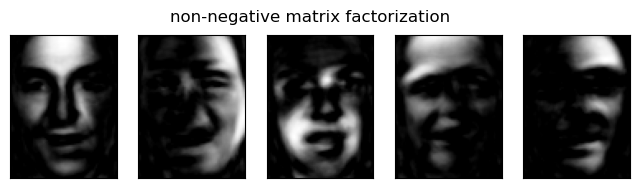

In [84]:
image_shape = people.images[0].shape
x_train, x_test, y_train, y_test = train_test_split(
    x_people, y_people, stratify=y_people, random_state=0)
nmf = NMF(n_components=100, random_state=0)
nmf.fit(x_train)

x_reconstructed_nmf = np.dot(nmf.transform(x_test), nmf.components_)

fig, axes = plt.subplots(1, 5, figsize=(8, 2),
                        subplot_kw={'xticks': (), 'yticks': ()})
fig.suptitle('non-negative matrix factorization')
for ax, comp_nmf in zip(axes.T, nmf.components_):
    ax.imshow(comp_nmf.reshape(image_shape), cmap='Greys_r')

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Cluster memberships:
[9 2 5 4 2 7 9 6 9 6 1 0 2 6 1 9 3 0 3 1 7 6 8 6 8 5 2 7 5 8 9 8 6 5 3 7 0
 9 4 5 0 1 3 5 2 8 9 1 5 6 1 0 7 4 6 3 3 6 3 8 0 4 2 9 6 4 8 2 8 4 0 4 0 5
 6 4 5 9 3 0 7 8 0 7 5 8 9 8 0 7 3 9 7 1 7 2 2 0 4 5 6 7 8 9 4 5 4 1 2 3 1
 8 8 4 9 2 3 7 0 9 9 1 5 8 5 1 9 5 6 7 9 1 4 0 6 2 6 4 7 9 5 5 3 8 1 9 5 6
 3 5 0 2 9 3 0 8 6 0 3 3 5 6 3 2 0 2 3 0 2 6 3 4 4 1 5 6 7 1 1 3 2 4 7 2 7
 3 8 6 4 1 4 3 9 9 5 1 7 5 8 2]


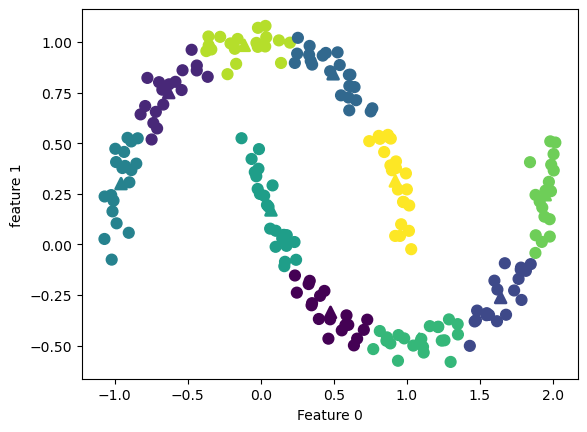

In [12]:
x, y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(x)
y_pred = kmeans.predict(x)

plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=60,
            marker='^', c=range(kmeans.n_clusters), linewidth=2)
plt.xlabel('Feature 0')
plt.ylabel('feature 1')
print('Cluster memberships:\n{}'.format(y_pred))

In [13]:
distance_features = kmeans.transform(x)
print('Distance feature shape: {}'.format(distance_features.shape))
print('Distance features:\n{}'.format(distance_features))

Distance feature shape: (200, 10)
Distance features:
[[0.9220768  1.46553151 1.13956805 ... 1.16559918 1.03852189 0.23340263]
 [1.14159679 2.51721597 0.1199124  ... 0.70700803 2.20414144 0.98271691]
 [0.78786246 0.77354687 1.74914157 ... 1.97061341 0.71561277 0.94399739]
 ...
 [0.44639122 1.10631579 1.48991975 ... 1.79125448 1.03195812 0.81205971]
 [1.38951924 0.79790385 1.98056306 ... 1.97788956 0.23892095 1.05774337]
 [1.14920754 2.4536383  0.04506731 ... 0.57163262 2.11331394 0.88166689]]


## Agglomerative Clustering

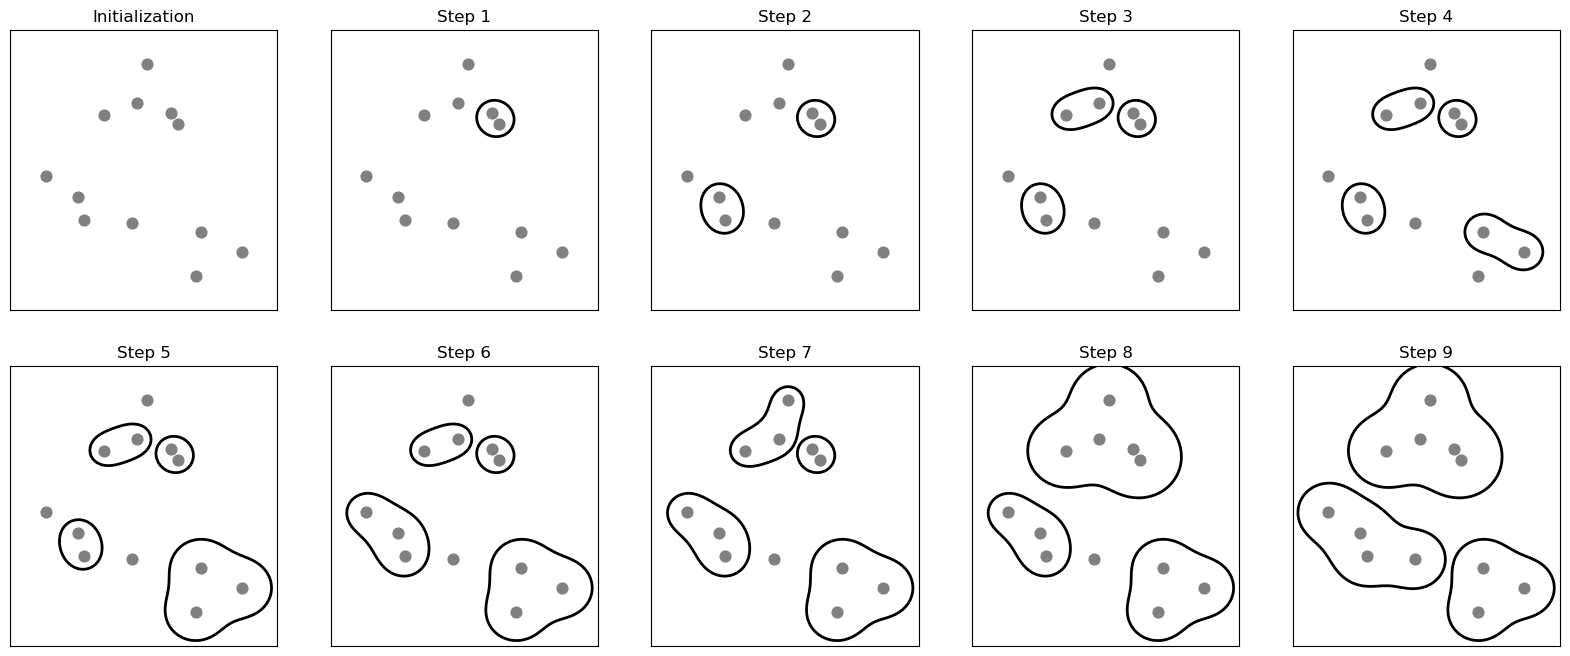

In [15]:
mglearn.plots.plot_agglomerative_algorithm()

Text(0, 0.5, 'Feature 1')

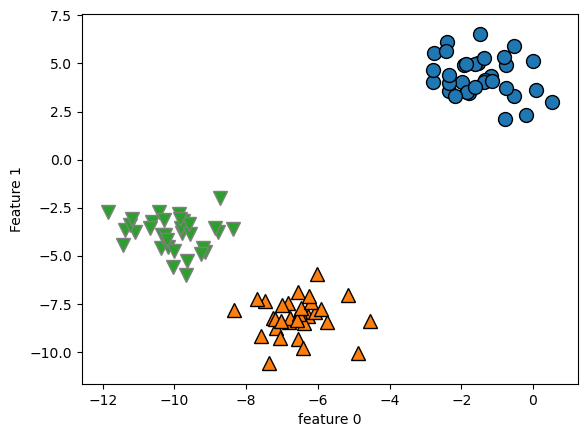

In [17]:
from sklearn.cluster import AgglomerativeClustering
x, y = make_blobs(random_state=1)

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(x)

mglearn.discrete_scatter(x[:, 0], x[:, 1], assignment)
plt.xlabel('feature 0')
plt.ylabel('Feature 1')

## Hierarchical clustering and dendrograms

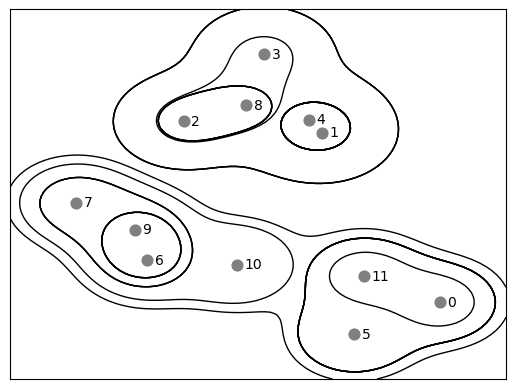

In [19]:
mglearn.plots.plot_agglomerative()

Text(0, 0.5, 'Cluster distance')

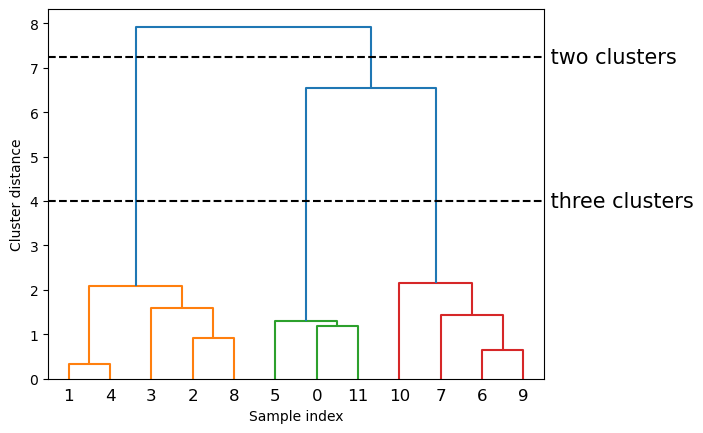

In [21]:
# import the denderogram function and the ward clustering function from scipy
from scipy.cluster.hierarchy import dendrogram, ward

x, y = make_blobs(random_state=0, n_samples=12)

# Apply the ward clustering to the data array x
# The SciPy ward function returns an aray that specifies the distances
# bridged when performing agglomerative clustering
linkage_array = ward(x)

# Now we plot the dendrogram for the linkage_array containing the distances
# between clusters
dendrogram(linkage_array)

# Mark the cuts in the tree that signify two or three clusters
ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')

ax.text(bounds[1], 7.25, ' two clusters', va='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' three clusters', va='center', fontdict={'size': 15})
plt.xlabel('Sample index')
plt.ylabel('Cluster distance')

## DBSCAN

In [22]:
from sklearn.cluster import DBSCAN
x, y = make_blobs(random_state=0, n_samples=12)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x)
print('Cluster memberships:\n{}'.format(clusters))

Cluster memberships:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


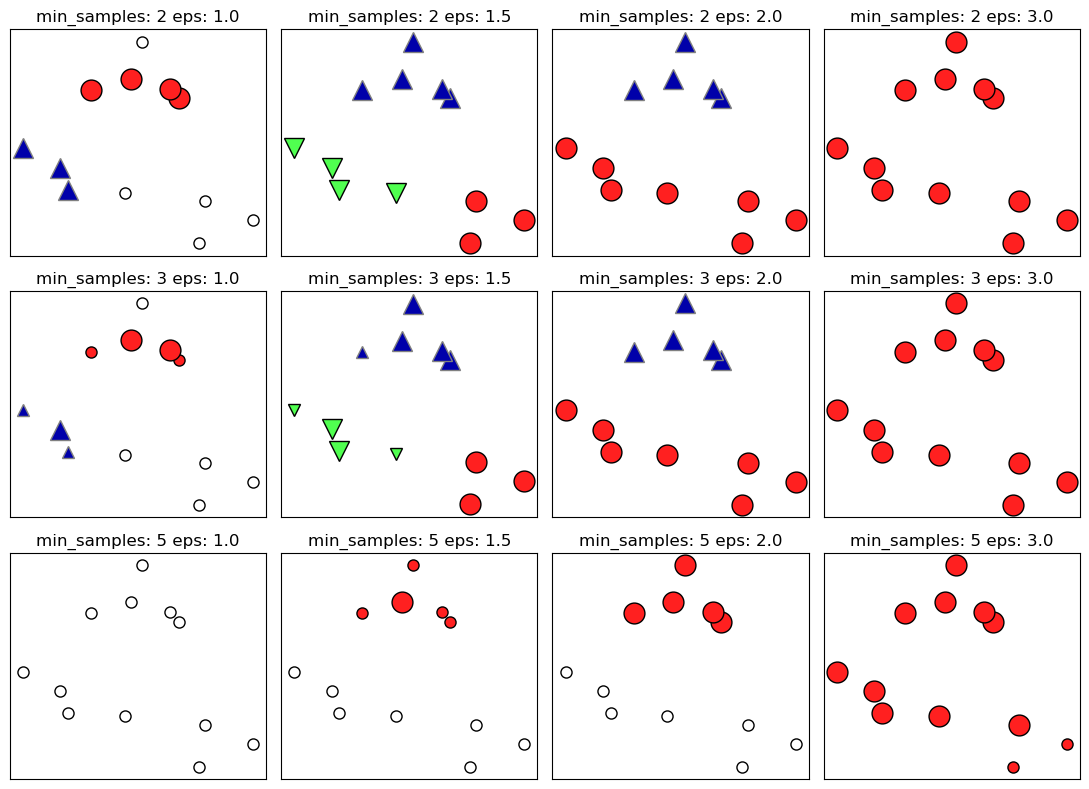

In [23]:
mglearn.plots.plot_dbscan()

Text(0, 0.5, 'Feature 1')

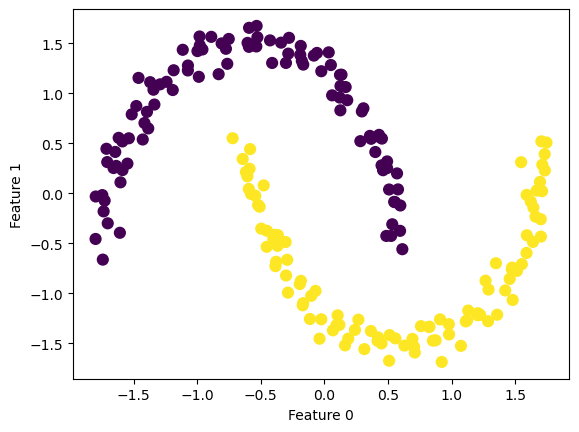

In [28]:
from sklearn.preprocessing import StandardScaler
x, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# rescale the data to zero mean and unit variance
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x_scaled)

# plot the cluster assignments
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters, s=60)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

## Comparing and Evaluating Clustering Algorithms

## Evaluating clustering with ground truth

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


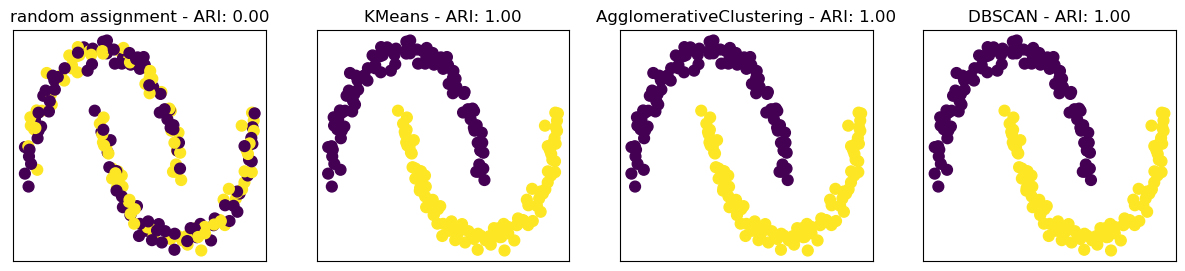

In [34]:
from sklearn.metrics.cluster import adjusted_rand_score


x, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# rescale the data to zero mean and unit variance
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

fig, axes = plt.subplots(1, 4, figsize=(15, 3),
                        subplot_kw={'xticks': (), 'yticks': ()})

# make a list of algorithms to use
algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2),
             DBSCAN()]

# create a random cluster assignment for reference
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(x))

# plot random assignment
axes[0].scatter(x_scaled[:, 0], x_scaled[:, 1], c=random_clusters,
               s=60)
axes[0].set_title('random assignment - ARI: {:.2f}'.format(
        adjusted_rand_score(y, random_clusters)))

for ax, algorithm in zip(axes[1:], algorithms):
    # plot the cluster assignments and cluster centers
    cluster = algorithm.fit_predict(x_scaled)
    ax.scatter(x_scaled[:, 0], x_scaled[:, 1], c=clusters, s=60)
    ax.set_title('{} - ARI: {:.2f}'.format(algorithm.__class__.__name__, 
                                          adjusted_rand_score(y, clusters)))
    

In [46]:
from sklearn.metrics import accuracy_score

# these two labelings of points correspond to the same clustering
clusters1 = [0, 0, 1, 1, 0]
clusters2 = [1, 1, 0, 0, 1]

# accuracy is zero, as none of the labels are the same
print('Accuracy: {:.2f}'.format(accuracy_score(clusters1,clusters2)))

# adjusted rand score is 1, as the clustering is excatly the same
print('ARI: {:.2f}'.format(adjusted_rand_score(clusters1, clusters2)))

Accuracy: 0.00
ARI: 1.00


## Comparing algorithms on the faces dataset

In [49]:
# extract eigenfaces from lfw data and transform data
from sklearn.decomposition import PCA
pca = PCA(n_components=100, whiten=True, random_state=0)
pca.fit_transform(x_people)
x_pca = pca.transform(x_people)

## Analyzing the faces dataset with DBSCAN

In [50]:
# apply DBSCAN withdefault parameters
dbscan = DBSCAN()
labels = dbscan.fit_predict(x_pca)
print('Unique labels: {}'.format(np.unique(labels)))

Unique labels: [-1]


In [51]:
dbscan = DBSCAN(min_samples=3, eps=15)
labels = dbscan.fit_predict(x_pca)
print('Unique labels: {}'.format(np.unique(labels)))

Unique labels: [-1  0]


In [52]:
# Count number of points in all clusters and noise
# bincount doesn't allow negative numbers, so we need to add 1
# The first number in the result corresponds to the noise points.
print('Number of points per cluster: {}'.format(np.bincount(labels+1)))

Number of points per cluster: [  37 2026]


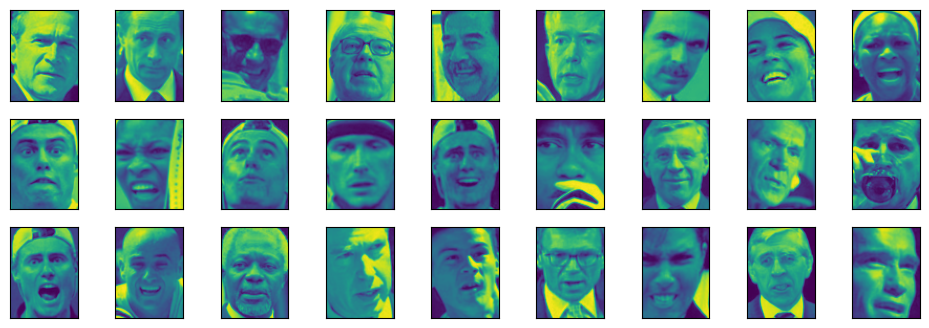

In [55]:
noise = x_people[labels==-1]
image_shape = people.images[0].shape
fig, axes = plt.subplots(3, 9, subplot_kw={'xticks': (), 'yticks': ()},
                        figsize=(12, 4))
for image, ax in zip(noise, axes.ravel()):
    ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
    

In [58]:
for eps in [1, 3, 5, 7, 9, 11, 13]:
    print('\neps={}'.format(eps))
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(x_pca)
    print('Clusters present: {}'.format(np.unique(labels)))
    print('Clusters sizes: {}'.format(np.bincount(labels + 1)))
    


eps=1
Clusters present: [-1]
Clusters sizes: [2063]

eps=3
Clusters present: [-1]
Clusters sizes: [2063]

eps=5
Clusters present: [-1  0]
Clusters sizes: [2059    4]

eps=7
Clusters present: [-1  0  1  2  3  4  5]
Clusters sizes: [1957   75    4   14    6    4    3]

eps=9
Clusters present: [-1  0  1]
Clusters sizes: [1196  864    3]

eps=11
Clusters present: [-1  0]
Clusters sizes: [ 404 1659]

eps=13
Clusters present: [-1  0]
Clusters sizes: [ 119 1944]


In [67]:
dbscan = DBSCAN(min_samples=3, eps=7)
lables = dbscan.fit_predict(x_pca)

for cluster in range(max(labels) + 1):
    mask = labels == cluster
    n_images = np.sum(mask)
    fig, axes = plt.subplots(1, n_images, figsize=(n_images * 1.5, 4),
                            subplot_kw={'xticks': (), 'yticks': ()})
    for image, label, ax in zip(x_people[mask], y_people[mask], axes):     
        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
        ax.set_title(people.target_names[label].split()[-1])
        

Error in callback <function _draw_all_if_interactive at 0x000001820AB167A0> (for post_execute):


ValueError: Image size of 291600x400 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 291600x400 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 291600x400 with 1944 Axes>

# Analyzing the faces dataset with k-means

In [ ]:
# extract clusters with k-means 
km = KMeans(n_clusters=10, random_state=0)
labels_km = km.fit_predict(x_pca)
print('Cluster sizes k-means: {}'.format(np.bincount(labels_km))

In [ ]:
fig, axes = plt.subplots(2, 5, subplot_kw={'xticks': (), 'yticks': ()},
                        figsize=(12, 4))
for center, ax in zip(km.cluster_centers_, axes.ravel()):
    ax.imshow(pca.inverse_transform(center).reshape(image_shape),
             vmin=0, vmax=1)

In [ ]:
mglearn.plots.plot_kmeans_faces(km, pca, x_pca, x_pople, 
                               y_people, people.target_names)

## Analyzing the faces dataset with agglomerative clustering

In [ ]:
# extract clusters with ward agglomerative clustering
agglomerative = AgglomerativeClustering(n_clusters=10)
labels_agg = Agglomerative.fit_predict(x_pca)
print('Cluster sizes agglomeratove clustering: {}'.format(
    np.bincount(labels_agg)))

In [ ]:
print('ARI: {:.2f}'.format(adjusted_rand_score(labels_agg, labes_km)))

In [ ]:
linkage_array = ward(x_pca)

# now we plot the dendrogram for the linkage array
# containing the distances between clusters
plt.figure(figsiz=(20, 5))
dendrogram(linkage_array, p=7, truncate_model='level', no_labels=True)
plt.xlabel('Sample index')
plt.ylabel('Cluster distance')

In [ ]:
n_clusters = 10
fro cluster in range(n_clusters):
    mask = labels_agg = cluster
    fig, axes = plt.subplots(1, 10, subplot_kw={'xticks': (), 'yticks': ()},
                            figsize=(15, 8))
    axes[0].set_ylabel(np.sum(mask))
    for image, label, asdf, ax in zip(x_people[mask], y_people[mask], 
                                     labels_agg[mask], axes):
        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
        ax.set_title(people.target_names[label].split()[-1],
                    fontdict={'fontsize': 9})
        

In [ ]:
# extract clusters with ward agglomerative clustering
agglomerative = AgglomerativeClustering(n_clusters=40)
labels_agg = agglomerative.fit_predict(x_pca)
print('cluster sizes agglomerative clustering: {}'.format(np.bincount(labels_agg)))

n_clusters = 40
for cluster in [10, 13, 19, 22, 36]: # hand-picked "interesting" clusters
    mask = labels_agg = cluster
    fig, axes = plt.subplots(1, 15, subplot_kw={'xticks': (), 'yticks'},
                            figsize=(15, 8))
    cluster_size = np.sum(mask)
    axes[0].set_ylabel('#{}: {}'.format(cluster, cluster_size))
    for image, label, asdf, ax in zip(x_people[mask], y_people[mask],
                                      lables_agg[mask], axes):
        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
        ax.set_title(people.target_names[label].split()[-1],
                     fontdict={'fontsize': 9})
    for i in range(cluster_size, 15):
        axes[i].set_visible(False)